<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
EmployeeID          50 non-null int64
Name                48 non-null object
Department          49 non-null object
Experience_Years    49 non-null float64
Education_Level     43 non-null object
Age                 50 non-null int64
Gender              48 non-null object
City                47 non-null object
Monthly_Salary      49 non-null float64
dtypes: float64(2), int64(2), object(5)
memory usage: 3.6+ KB
EmployeeID           0.0
Name                 4.0
Department           2.0
Experience_Years     2.0
Education_Level     14.0
Age                  0.0
Gender               4.0
City                 6.0
Monthly_Salary       2.0
dtype: float64


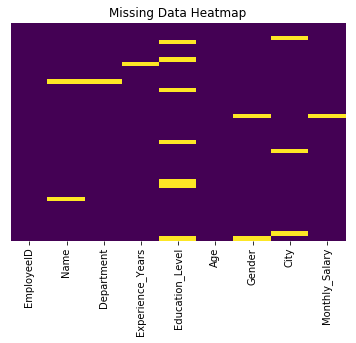

In [2]:

# coding: utf-8

# In[1]:


import pandas as pd

# Load CSV dataset
df = pd.read_csv("employee_salary_dataset.csv")

# Display first 5 rows
df.head()


# In[2]:


import pandas as pd

# Load CSV dataset
df = pd.read_csv("employee_salary_dataset.csv")

# Display first 5 rows
df.head()


# In[3]:


df.info()


# In[4]:


df.describe(include="all")


# In[5]:


df.isnull().sum()


# In[6]:


missing_percentage = df.isnull().mean() * 100
print(missing_percentage)


# In[7]:


import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Data Heatmap")
plt.show()


# In[8]:


df = df.dropna(subset=['Age'])


# In[9]:


df['Monthly_Salary'].fillna(df['Monthly_Salary'].mean(), inplace=True)


# In[10]:


df['Age'].fillna(df['Age'].median(), inplace=True)


# In[11]:


Q1 = df['Monthly_Salary'].quantile(0.25)
Q3 = df['Monthly_Salary'].quantile(0.75)

IQR = Q3 - Q1

df_cleaned = df[~((df['Monthly_Salary'] < (Q1 - 1.5 * IQR)) |
                  (df['Monthly_Salary'] > (Q3 + 1.5 * IQR)))]


# In[12]:


from scipy import stats
import numpy as np

z_scores = np.abs(stats.zscore(df['Monthly_Salary']))

df_no_outliers = df[z_scores < 3]


# In[13]:


df.duplicated().sum()


# In[14]:


df = df.drop_duplicates()


# In[16]:


df['Department'] = df['Department'].str.lower().str.strip()


# In[17]:


df['Department'].replace({
    'hr': 'human resources',
    'it dept': 'it'
}, inplace=True)
